In [44]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

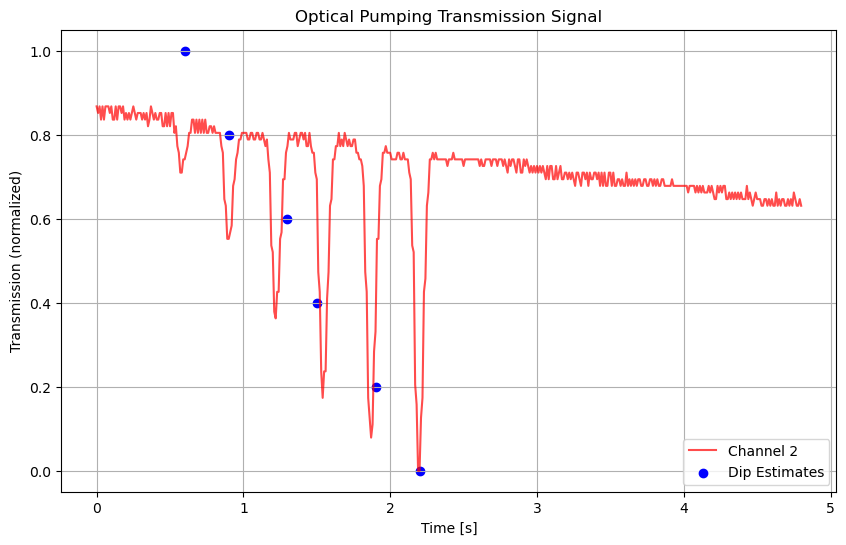

In [72]:
freq = 2.5
date = "Mar 16"
vHoriz = 304.5 # V
savename = "10s measurement " + date + " - " + str(freq).replace('.', 'p') + "MHz"
time, y1, y2, y2_norm = m.read_transmission_csv("./data/" + date + " measurement/" + str(freq).replace('.', 'p') + "MHz_10s.csv")
vHoriz = (vHoriz) / 1000
vShift = ufloat(vHoriz,0.0001)
t0 = 0.7 + 2.5
tf = 8
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]


y1_bottom = y1[nCutBeginning:len(time)-nCutEnd]
y2_bottom = y2_norm_cutFirst
time_cutFirst_bottom = time_cutFirst

x0s = np.array([3.1,3.4,3.8,4,4.4,4.7]) - 2.5

m.plot_quadraticZeeman_sextuple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)
p0 = (1, -0.02, 0.2, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3], 0.5, 0.1, x0s[4], 0.5, 0.1, x0s[5])
lower_bound = (0,-1,0,0,0.55,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,0.65,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.sextuple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

popt_bottom = popt
p0_bottom = p0

# print(len(popt_bottom))

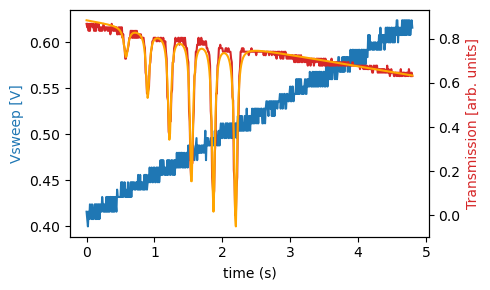

In [73]:
# m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)

# plt.figure(figsize=(5,1.5))

fig, ax1 = plt.subplots(figsize=(5,3))

color = 'tab:blue'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Vsweep [V]', color=color)  # we already handled the x-label with ax1
ax1.plot(time_cutFirst, y1[nCutBeginning:len(time)-nCutEnd], label='Vsweep', color=color)

# ax1.legend(loc="center left")

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:red'
# ax2.set_xlabel('time (s)')
ax2.set_ylabel('Transmission [arb. units]', color=color)
ax2.plot(time_cutFirst, y2_norm_cutFirst, label='Photodetector', color=color)
plt.plot(time_cutFirst, m.sextuple_lorentz(time_cutFirst, *popt), label='Lorentzian Fit', color='orange')

# ax2.legend(loc="center left")
# plt.xlabel('Time (s)')

plt.tight_layout()  # otherwise the right y-label is slightly clipped
# plt.savefig("figures/fit to " + savename + " with Vsweep.pdf", dpi=300)
# fig.legend()
plt.show()


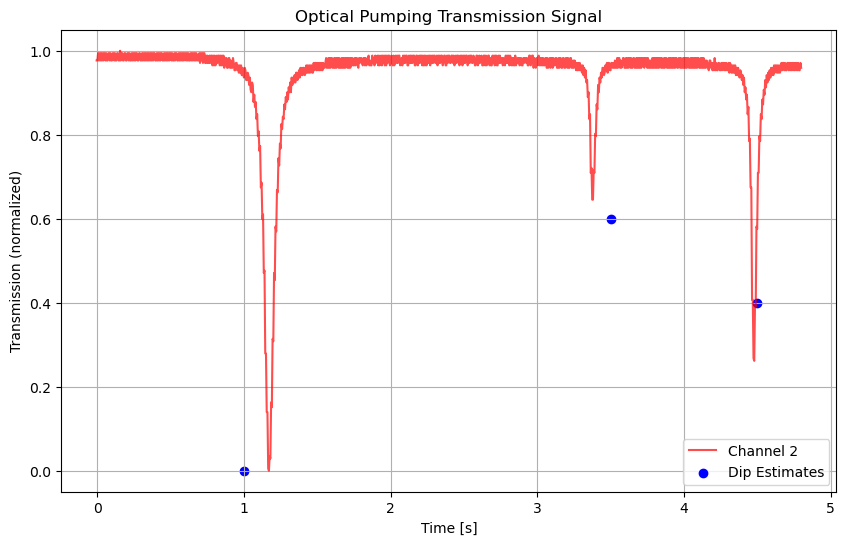

In [74]:
freq = 175
savename = "Mar 9 - " + str(freq) + 'kHz'
# time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/NewFile' + str(freq) + 'kHz' + '.csv')
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 9 measurement/NewFile175kHz.csv')

t0 = 1
tf = 5.8
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]


x0s = np.array([1,3.5,4.5])

y1_top = (y1[nCutBeginning:len(time)-nCutEnd])/10
y2_top = y2_norm_cutFirst
time_cutFirst_top = time_cutFirst


m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.triple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

popt_top = popt

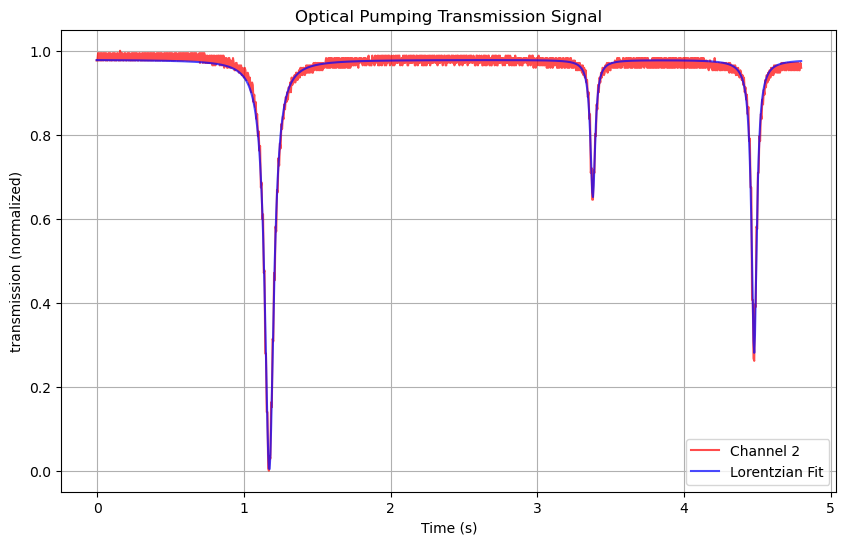

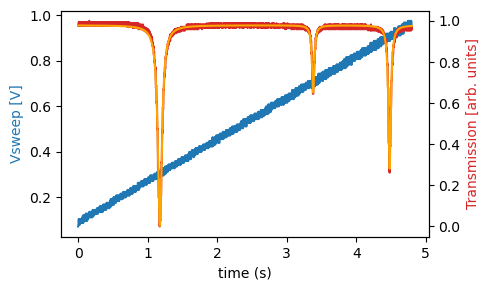

In [75]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.triple_lorentz, "fit to " + savename)


# m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)

# plt.figure(figsize=(5, 1.5))

fig, ax1 = plt.subplots(figsize=(5,3))

color = 'tab:blue'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Vsweep [V]', color=color)  # we already handled the x-label with ax1
ax1.plot(time_cutFirst, y1[nCutBeginning:len(time)-nCutEnd]/10, label='Vsweep', color=color)

# ax1.legend(loc="center left")

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:red'
# ax2.set_xlabel('time (s)')
ax2.set_ylabel('Transmission [arb. units]', color=color)
ax2.plot(time_cutFirst, y2_norm_cutFirst, label='Photodetector', color=color)
plt.plot(time_cutFirst, m.triple_lorentz(time_cutFirst, *popt), label='Lorentzian Fit', color='orange')

# ax2.legend(loc="center left")
# plt.xlabel('Time (s)')

plt.tight_layout()  # otherwise the right y-label is slightly clipped
# plt.savefig("figures/fit to " + savename + " with Vsweep.pdf", dpi=300)
# fig.legend()
plt.show()


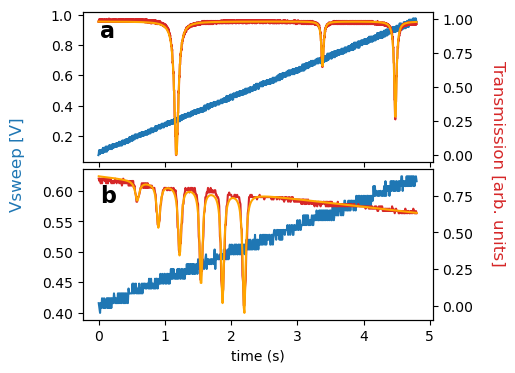

In [77]:
# Set a larger height since you're stacking two 1.5-inch plots
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(5, 4), sharex=True)

# --- TOP PLOT (ax1 and ax2) ---
color_sweep = 'tab:blue'
# ax1.set_ylabel('Vsweep [V]', color=color_sweep)
ax1.plot(time_cutFirst_top, y1_top, markersize=3, color=color_sweep)
ax1.text(0.05, 0.95, 'a', transform=ax1.transAxes, fontsize=16, color='black', fontweight='bold', va='top')

ax2 = ax1.twinx()
color_trans = 'tab:red'
# ax2.set_ylabel('Transmission [arb. units]', color=color_trans)
ax2.plot(time_cutFirst_top, y2_top, markersize=3, color=color_trans)
ax2.plot(time_cutFirst_top, m.triple_lorentz(time_cutFirst_top, *popt_top), markersize=3, color='orange')

# --- BOTTOM PLOT (ax3 and ax4) ---
ax3.set_xlabel('time (s)')
# ax3.set_ylabel('Vsweep [V]', color=color_sweep)
ax3.plot(time_cutFirst_bottom, y1_bottom, markersize=3, color=color_sweep)
ax3.text(0.05, -0.15, 'b', transform=ax1.transAxes, fontsize=16, color='black', fontweight='bold', va='top')

ax4 = ax3.twinx()
# ax4.set_ylabel('Transmission [arb. units]', color=color_trans)
ax4.plot(time_cutFirst_bottom, y2_bottom, markersize=3, color=color_trans)
ax4.plot(time_cutFirst_bottom, m.sextuple_lorentz(time_cutFirst_bottom, *popt_bottom), markersize=3, color='orange')

# Remove vertical space between subplots
plt.subplots_adjust(hspace=0.05)
# fig.supylabel('Vsweep [V]', color=color_sweep, x=0.02)
# fig.supylabel('Transmission [arb. units]',
#               color=color_trans,
#               x=0.98,
#               rotation=270)

fig.text(0.02, 0.5, 'Vsweep [V]',
         va='center', ha='center', rotation='vertical',
         color=color_sweep, fontsize=12)

fig.text(0.98, 0.5, 'Transmission [arb. units]',
         va='center', ha='center', rotation=270,
         color=color_trans, fontsize=12)
plt.subplots_adjust(left=0.15, right=0.85, hspace=0.05)

plt.savefig("figures/combined_stack_low+highB_oscilloscope.pdf", dpi=300, bbox_inches='tight')
plt.show()